In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [69]:
customers_df = pd.read_excel(r'E:\\DS\\tezendra\\Projects\\E-Commerce\Datasets\\customer_data.xlsx')
customers_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No


In [70]:
missing_values = customers_df.isnull().sum()
print('missing values in each column:\n', missing_values)


missing values in each column:
 CustomerID                  0
Gender                      0
Age                         0
Income                      5
City                        3
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64


In [71]:
from sklearn.impute import SimpleImputer

In [72]:
imputer = SimpleImputer(strategy='median')   
imputer_2 = SimpleImputer(strategy='most_frequent')

customers_df['Income'] = imputer.fit_transform(customers_df[['Income']])[:,0]
customers_df['City'] = imputer_2.fit_transform(customers_df[['City']])[:,0]


In [73]:
missing_values = customers_df.isnull().sum()
print('missing values in each column:\n', missing_values)

missing values in each column:
 CustomerID                  0
Gender                      0
Age                         0
Income                      0
City                        0
Region                      0
Frequency_of_Purchases      0
Average_Purchase_Amount     0
Customer_Lifespan_Months    0
Purchase_Channel            0
Date_of_Purchase            0
Churn_Status                0
dtype: int64


In [74]:
customers_df['Customer_Lifespan_Months'].unique()

array([3, 4, 1, 2, 5, 'XXXX'], dtype=object)

In [75]:
customers_df = customers_df[customers_df['Customer_Lifespan_Months'] != 'XXXX']
customers_df['Customer_Lifespan_Months'].unique()

array([3, 4, 1, 2, 5], dtype=object)

In [76]:
customers_df['Customer_Lifespan_Months'] = customers_df['Customer_Lifespan_Months'].astype(int)
customers_df['Date_of_Purchase'] = customers_df['Date_of_Purchase'].astype('datetime64[ns]')
customers_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 80
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   CustomerID                80 non-null     object        
 1   Gender                    80 non-null     object        
 2   Age                       80 non-null     int64         
 3   Income                    80 non-null     float64       
 4   City                      80 non-null     object        
 5   Region                    80 non-null     object        
 6   Frequency_of_Purchases    80 non-null     int64         
 7   Average_Purchase_Amount   80 non-null     float64       
 8   Customer_Lifespan_Months  80 non-null     int64         
 9   Purchase_Channel          80 non-null     object        
 10  Date_of_Purchase          80 non-null     datetime64[ns]
 11  Churn_Status              80 non-null     object        
dtypes: datetime64[ns](1), float64

In [77]:
dup_cus = customers_df.duplicated()
customers_df[dup_cus]

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
80,C021,Female,22,41743.0,Los Angeles,Northeast,4,54.599,1,Online,2023-06-08,No


In [78]:
customers_df.drop_duplicates(inplace=True)
customers_df[dup_cus]

C:\Users\thapa\AppData\Local\Temp\ipykernel_24964\1656588182.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  customers_df[dup_cus]


,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status


In [79]:
sorted_df = customers_df.sort_values(by='Income', ascending=False)
sorted_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status
55,C056,Female,29,107662.0,Houston,Northeast,3,47.877,1,In-store,2022-02-11,No
22,C023,Female,41,105186.0,Los Angeles,Midwest,14,137.697,4,Online,2023-07-15,Yes
70,C071,Female,36,103264.0,Los Angeles,Northeast,11,117.394,3,Online,2023-12-22,Yes
32,C033,Female,31,98590.0,Houston,West,7,76.114,2,Online,2023-06-30,No
52,C053,Female,45,90860.0,Houston,Northeast,10,105.287,3,In-store,2023-12-29,Yes


In [80]:
customers_df.loc[0:5, 'CustomerID':'Region']

,CustomerID,Gender,Age,Income,City,Region
0,C001,Male,49,72504.0,Chicago,Northeast
1,C002,Female,38,40881.0,New York,West
2,C003,Male,17,63333.0,New York,Northeast
3,C004,Male,34,58030.0,Chicago,Midwest
4,C005,Male,30,78889.0,Houston,Midwest
5,C006,Male,52,76470.0,Chicago,Midwest


In [81]:
customers_df.iloc[0:5, 0:5] 

,CustomerID,Gender,Age,Income,City
0,C001,Male,49,72504.0,Chicago
1,C002,Female,38,40881.0,New York
2,C003,Male,17,63333.0,New York
3,C004,Male,34,58030.0,Chicago
4,C005,Male,30,78889.0,Houston


In [82]:
male_customers = customers_df[customers_df['Gender'] == 'Male']
print(male_customers.head(5))

  CustomerID Gender  Age   Income      City     Region  \
0       C001   Male   49  72504.0   Chicago  Northeast   
2       C003   Male   17  63333.0  New York  Northeast   
3       C004   Male   34  58030.0   Chicago    Midwest   
4       C005   Male   30  78889.0   Houston    Midwest   
5       C006   Male   52  76470.0   Chicago    Midwest   

   Frequency_of_Purchases  Average_Purchase_Amount  Customer_Lifespan_Months  \
0                      10                   98.241                         3   
2                       1                   41.252                         1   
3                       6                   67.329                         1   
4                       3                   52.763                         1   
5                      11                  117.012                         3   

  Purchase_Channel Date_of_Purchase Churn_Status  
0           Online       2022-03-05          Yes  
2           Online       2023-01-30           No  
3         In-stor

In [83]:
Freq_male = male_customers[male_customers['Frequency_of_Purchases'] > 5 ]
print(Freq_male.head(5))

  CustomerID Gender  Age   Income         City     Region  \
0       C001   Male   49  72504.0      Chicago  Northeast   
3       C004   Male   34  58030.0      Chicago    Midwest   
5       C006   Male   52  76470.0      Chicago    Midwest   
7       C008   Male   38  38401.0      Houston       West   
8       C009   Male   44  73105.0  Los Angeles  Northeast   

   Frequency_of_Purchases  Average_Purchase_Amount  Customer_Lifespan_Months  \
0                      10                   98.241                         3   
3                       6                   67.329                         1   
5                      11                  117.012                         3   
7                       6                   70.730                         2   
8                      12                  124.887                         3   

  Purchase_Channel Date_of_Purchase Churn_Status  
0           Online       2022-03-05          Yes  
3         In-store       2023-06-01           No  

In [84]:
performance_df = pd.read_excel(r'E:\\DS\\tezendra\\Projects\\E-Commerce\Datasets\\performance_data.xlsx')
performance_df.head(5)

,CustomerID,Recency,Frequency_Score,Monetary_Score
0,C001,3,2,2
1,C002,3,3,3
2,C003,4,4,4
3,C004,2,2,2
4,C005,1,1,1


In [85]:
joined_df = customers_df.merge(performance_df, on='CustomerID', how='inner')
joined_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23,No,1,1,1


In [86]:
additional_data_df = pd.read_excel(r'E:\\DS\\tezendra\\Projects\\E-Commerce\Datasets\\additional_data.xlsx')
additional_data_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,CustomerID.1,Recency,Frequency_Score,Monetary_Score
0,C081,Male,37,50728,Chicago,West,11,75.757,2,In-store,2023-09-10,Yes,C081,2,2,1
1,C082,Female,48,69629,Los Angeles,Midwest,9,78.433,4,In-store,2023-07-15,No,C082,3,4,4
2,C083,Male,28,29184,Chicago,Northeast,7,82.794,3,Online,2023-08-25,Yes,C083,3,1,2
3,C084,Female,33,61265,Los Angeles,West,15,88.490,2,Online,2022-10-22,Yes,C084,4,1,3
4,C085,Female,30,63130,Houston,Midwest,13,108.749,3,Online,2023-04-01,Yes,C085,4,4,1


In [87]:
final_df = pd.concat([joined_df.reset_index(drop=True), additional_data_df.reset_index(drop=True)])
final_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,CustomerID.1
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,NaN
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,NaN
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,NaN
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,NaN
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,NaN


In [88]:
final_df = (final_df.drop(columns=['CustomerID.1'], axis=1))
final_df.head(5)

,CustomerID,Gender,Age,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score
0,C001,Male,49,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2
1,C002,Female,38,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3
2,C003,Male,17,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4
3,C004,Male,34,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2
4,C005,Male,30,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1


In [89]:
freq_purchase_channel = final_df['Purchase_Channel'].value_counts()
freq_purchase_channel

Purchase_Channel
Online      65
In-store    34
Name: count, dtype: int64

In [90]:
Perc_purchase_channel = freq_purchase_channel / len(final_df) * 100
Perc_purchase_channel

Purchase_Channel
Online      65.656566
In-store    34.343434
Name: count, dtype: float64

In [91]:
round(final_df.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,99.0,99.0,99.0,99.0,99.0,99.0,99.0,99.0
mean,35.0,58115.0,9.0,135687.0,3.0,3.0,3.0,3.0
std,10.0,18618.0,3.0,1349094.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45724.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,98.0,3.0,3.0,3.0,3.0
75%,42.0,71484.0,12.0,121.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,13423412.0,5.0,4.0,4.0,4.0


In [92]:
final_df = final_df[final_df['Average_Purchase_Amount'] != 13423411.958]

In [93]:
round(final_df.describe())

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,98.0,98.0,98.0,98.0,98.0,98.0,98.0,98.0
mean,35.0,58131.0,9.0,98.0,3.0,3.0,3.0,3.0
std,10.0,18713.0,3.0,29.0,1.0,1.0,1.0,1.0
min,17.0,15531.0,1.0,37.0,0.0,1.0,1.0,1.0
25%,28.0,45482.0,7.0,76.0,2.0,2.0,2.0,2.0
50%,35.0,58033.0,10.0,97.0,3.0,3.0,3.0,3.0
75%,42.0,71994.0,12.0,120.0,3.0,4.0,4.0,4.0
max,54.0,107662.0,16.0,193.0,5.0,4.0,4.0,4.0


In [94]:
city_purchase_amount = final_df.groupby('City')['Average_Purchase_Amount'].median()
city_purchase_amount

City
Chicago        102.1860
Houston         87.6615
Los Angeles    100.7250
New York        94.4690
Name: Average_Purchase_Amount, dtype: float64

In [95]:
pivot_table = final_df.pivot_table(index = 'Churn_Status', 
                                     values = ['Recency', 'Frequency_Score', 'Monetary_Score'], 
                                     aggfunc = {'Recency':'mean', 'Frequency_Score':'mean', 'Monetary_Score':'mean', 'Churn_Status':'count'})

In [96]:
pivot_table = pivot_table.rename(columns = {'Churn_Status':'Freq_churn', 
                                            'Recency':'Mean_recency', 
                                            'Frequency_Score':'Mean_FS', 'Monetary_Score':'Mean_MS'})

pivot_table


,Freq_churn,Mean_FS,Mean_MS,Mean_recency
Churn_Status,,,,
No,43,2.744186,2.558140,2.720930
Yes,55,2.509091,2.509091,2.618182


In [97]:
cross_tab = pd.crosstab(final_df['City'], final_df['Churn_Status'])
cross_tab

Churn_Status,No,Yes
City,,
Chicago,8,17
Houston,16,16
Los Angeles,10,14
New York,9,8


In [98]:
num_variables = final_df.select_dtypes(include = ['number']).columns
correl = round(final_df[num_variables].corr(), 3)
correl


,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
Age,1.000,0.110,0.301,0.170,0.334,-0.048,-0.006,0.065
Income,0.110,1.000,-0.022,0.023,0.068,0.178,0.163,0.162
Frequency_of_Purchases,0.301,-0.022,1.000,0.704,0.762,-0.063,-0.065,-0.066
Average_Purchase_Amount,0.170,0.023,0.704,1.000,0.690,-0.029,-0.145,-0.191
Customer_Lifespan_Months,0.334,0.068,0.762,0.690,1.000,-0.073,-0.013,-0.001
Recency,-0.048,0.178,-0.063,-0.029,-0.073,1.000,0.761,0.743
Frequency_Score,-0.006,0.163,-0.065,-0.145,-0.013,0.761,1.000,0.819
Monetary_Score,0.065,0.162,-0.066,-0.191,-0.001,0.743,0.819,1.000


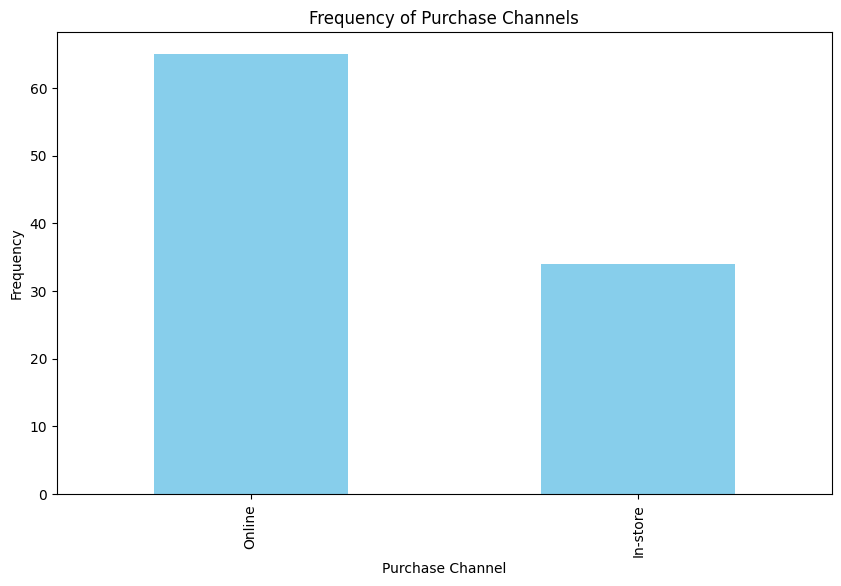

In [99]:
plt.figure(figsize=(10,6))
freq_purchase_channel.plot(kind='bar', color='skyblue')
plt.title('Frequency of Purchase Channels')
plt.xlabel('Purchase Channel')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

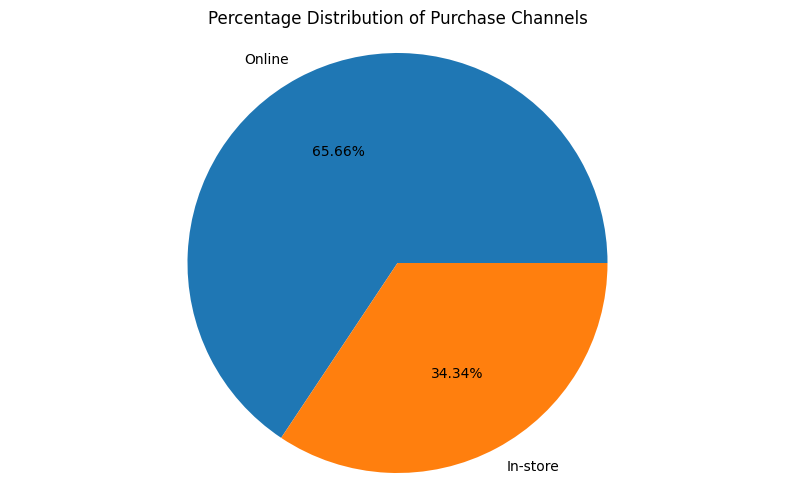

In [100]:
plt.figure(figsize=(10,6))
plt.pie(Perc_purchase_channel, labels=Perc_purchase_channel.index, autopct='%1.2f%%')
plt.title('Percentage Distribution of Purchase Channels')
plt.axis('equal')
plt.show()

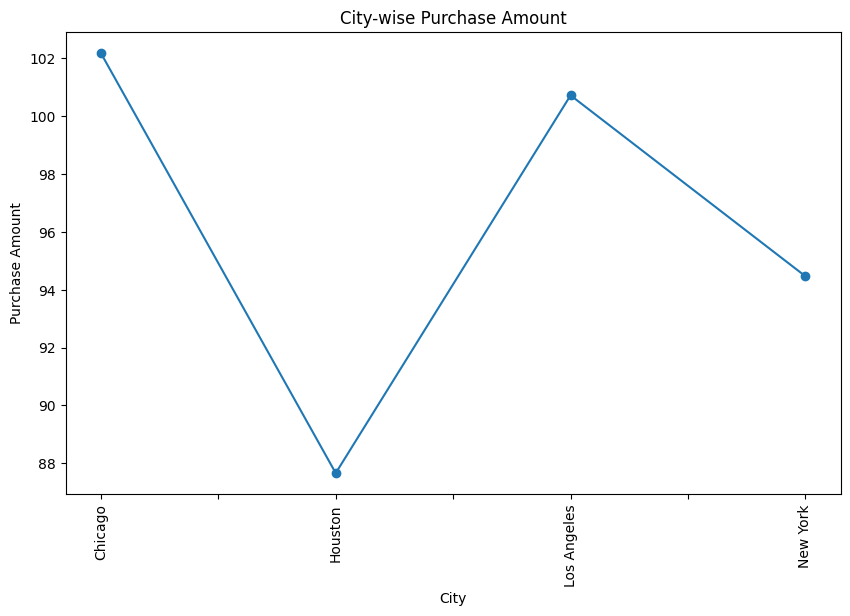

In [101]:
plt.figure(figsize=(10,6))
city_purchase_amount.plot(kind='line', marker='o')
plt.title('City-wise Purchase Amount')
plt.xlabel('City')
plt.ylabel('Purchase Amount')
plt.xticks(rotation=90)
plt.show()

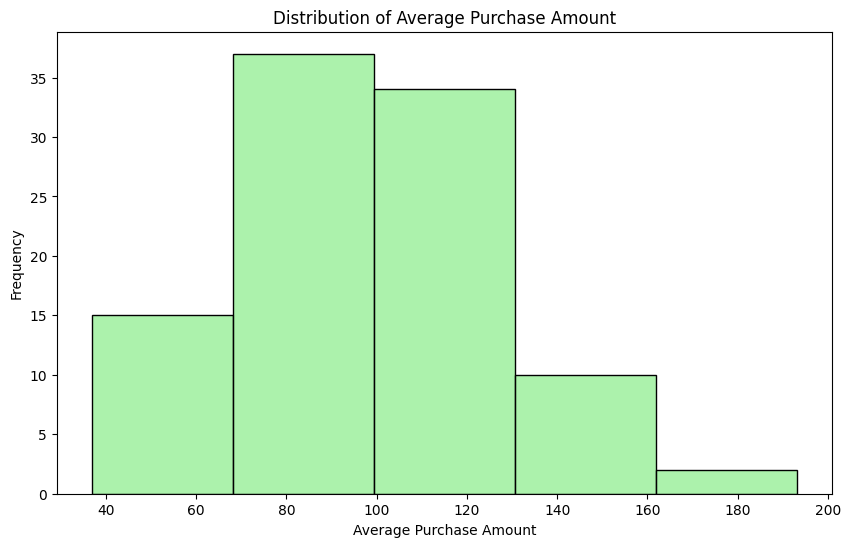

In [102]:
plt.figure(figsize=(10,6))
sns.histplot(final_df['Average_Purchase_Amount'], bins=5, color='lightgreen')
plt.title('Distribution of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

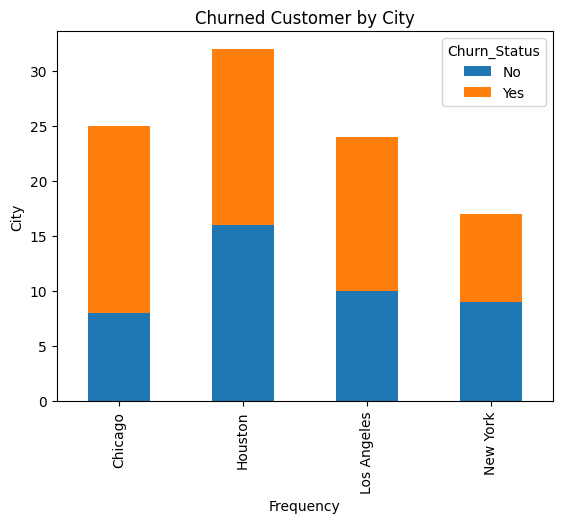

In [103]:
plt.figure(figsize= (10,6))
cross_tab.plot(kind = 'bar', stacked=True)
plt.title('Churned Customer by City')
plt.xlabel('Frequency')
plt.ylabel('City')
plt.show()


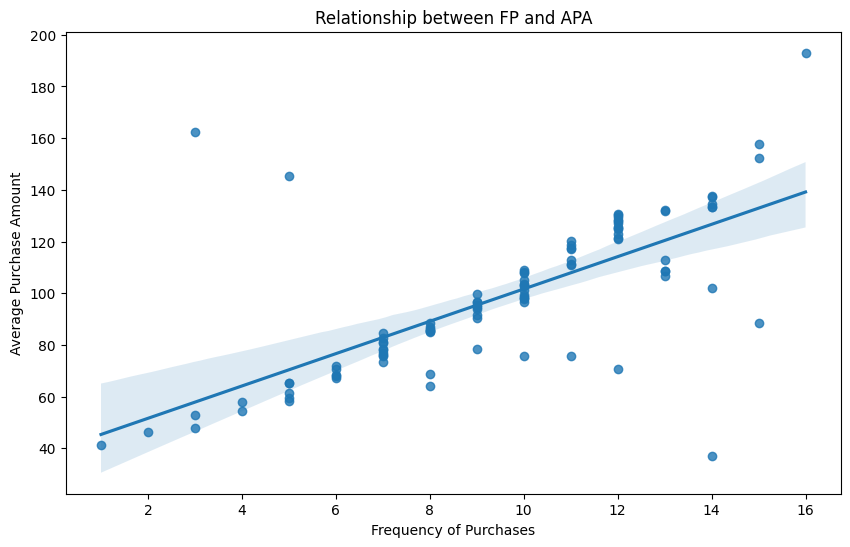

In [104]:
plt.figure(figsize = (10, 6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = final_df)
plt.title('Relationship between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

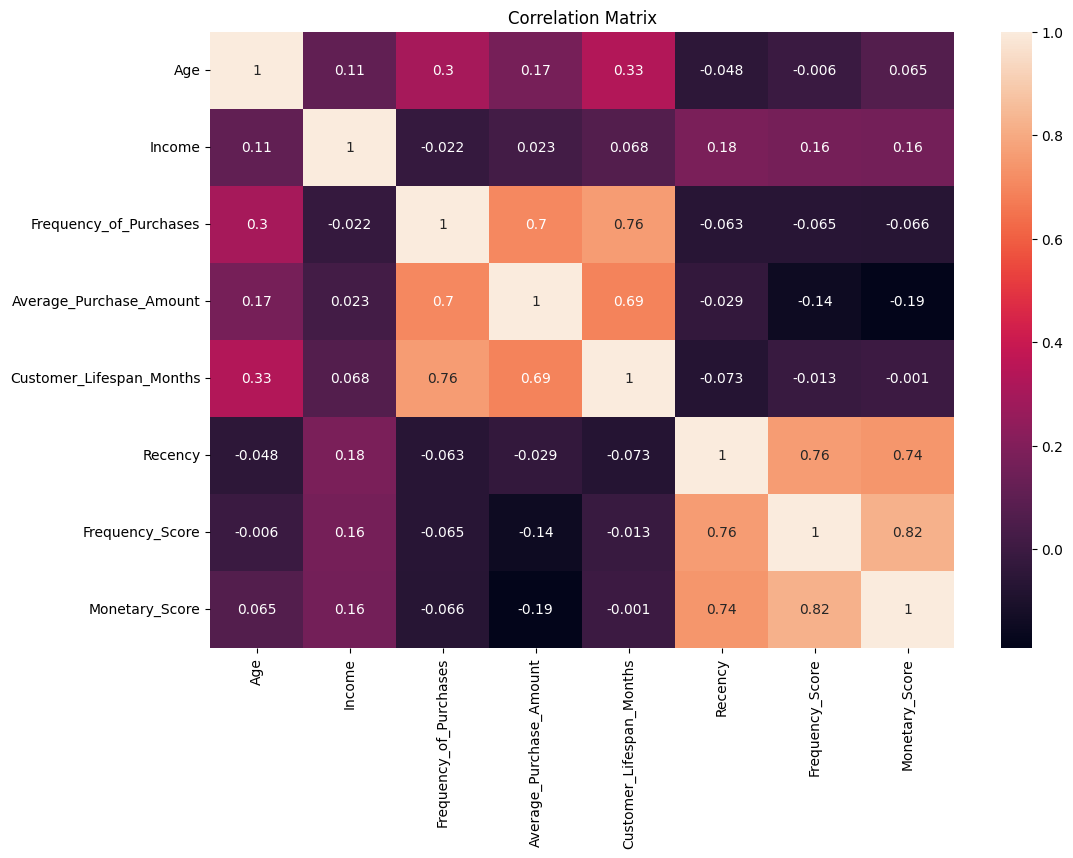

In [105]:
plt.figure(figsize = (12, 8))
sns.heatmap(correl, annot = True)
plt.title('Correlation Matrix')
plt.show()

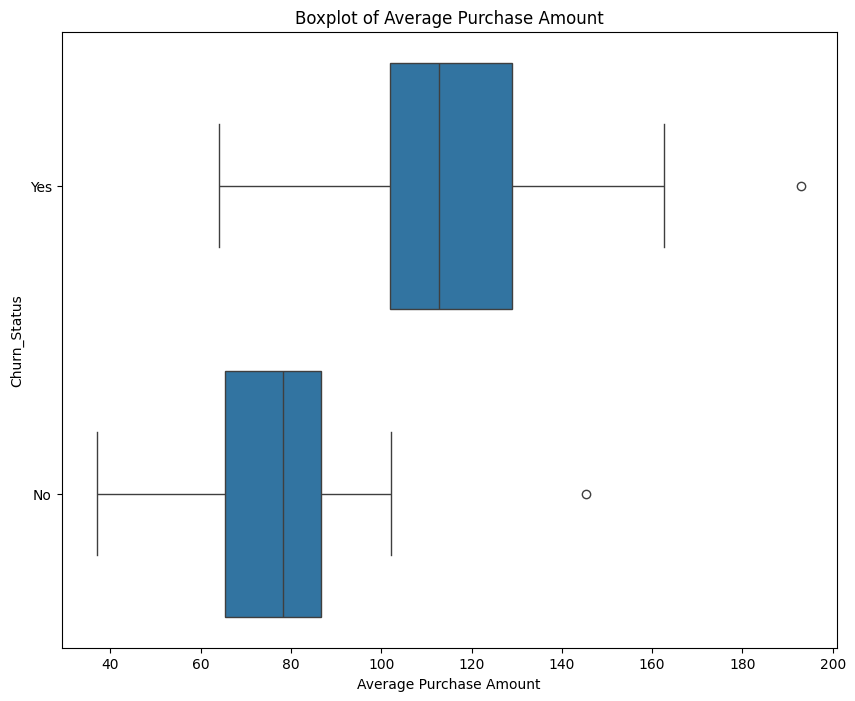

In [106]:
plt.figure(figsize = (10, 8))
sns.boxplot(x = 'Average_Purchase_Amount', y = 'Churn_Status', data = final_df)
plt.title('Boxplot of Average Purchase Amount')
plt.xlabel('Average Purchase Amount')
plt.show()

In [107]:
from scipy.stats import shapiro

In [108]:
final_df.describe()

,Age,Income,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Recency,Frequency_Score,Monetary_Score
count,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000,98.000000
mean,35.030612,58130.979592,9.428571,98.052806,2.540816,2.663265,2.612245,2.530612
std,9.850903,18712.728227,3.264934,29.009387,1.017054,1.139215,1.108846,1.114146
min,17.000000,15531.000000,1.000000,36.975000,0.000000,1.000000,1.000000,1.000000
25%,28.000000,45481.500000,7.000000,76.292000,2.000000,2.000000,2.000000,2.000000
50%,35.000000,58033.000000,10.000000,97.167500,3.000000,3.000000,3.000000,3.000000
75%,41.750000,71994.250000,12.000000,119.878000,3.000000,4.000000,4.000000,3.750000
max,54.000000,107662.000000,16.000000,193.046000,5.000000,4.000000,4.000000,4.000000


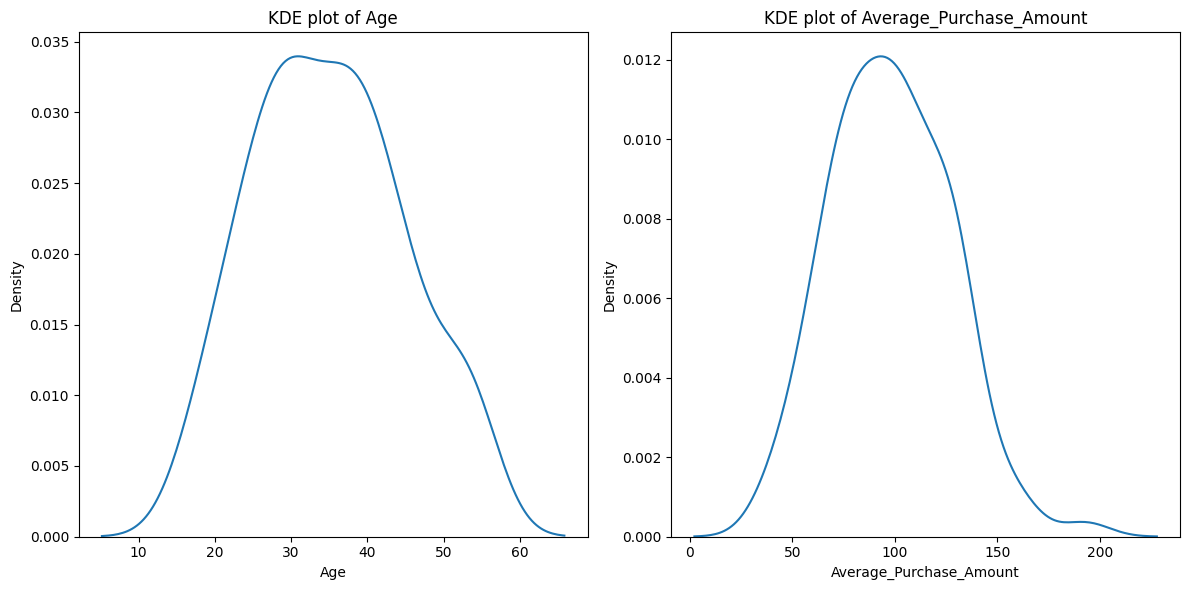

In [109]:
numeric_columns = ['Age', 'Average_Purchase_Amount']

fig, axes = plt.subplots(1, 2, figsize = (12, 6))

for index, column in enumerate(numeric_columns):
    sns.kdeplot(final_df[column], ax = axes[index])
    axes[index].set_title(f'KDE plot of {column}')
    
plt.tight_layout()
plt.show()

In [110]:
shapiro_results = {}
for column in numeric_columns:
    stat,p_value = shapiro(final_df[column])
    shapiro_results[column] = round(p_value, 3)
    
shapiro_results
    

{'Age': np.float64(0.037), 'Average_Purchase_Amount': np.float64(0.487)}

In [111]:
def sqrt_transform(data,column_name):
    data[f'{column_name}_sqrt'] = np.sqrt(data[column_name])
    stat,P_value = shapiro(data[f'{column_name}_sqrt'])
    distribution = sns.kdeplot(data[f'{column_name}_sqrt'])
    print(distribution)
    print('p-value:', p_value)
    

Axes(0.125,0.11;0.775x0.77)
p-value: 0.48733371043267265


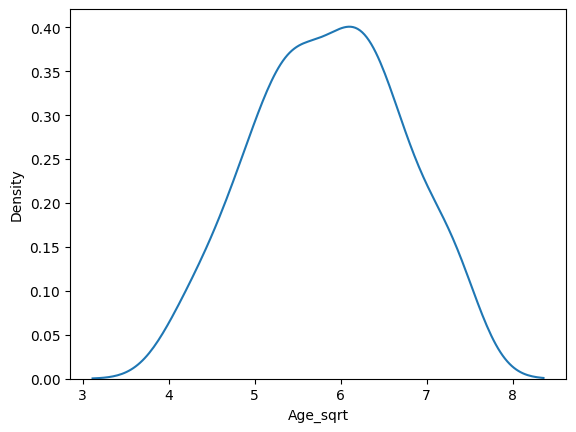

In [112]:
sqrt_transform(final_df, 'Age')

In [113]:
def log_transform(data,column_name):
    data[f'{column_name}_log'] = np.log(data[column_name])
    stat,P_value = shapiro(data[f'{column_name}_log'])
    distribution = sns.kdeplot(data[f'{column_name}_log'])
    print(distribution)
    print('p-value:', p_value)

Axes(0.125,0.11;0.775x0.77)
p-value: 0.48733371043267265


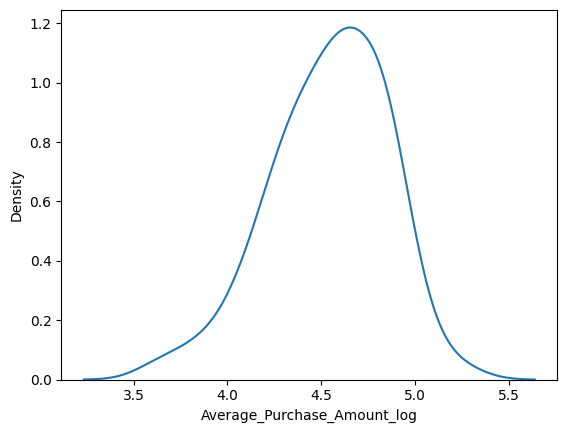

In [114]:
log_transform(final_df, 'Average_Purchase_Amount')

In [115]:
from scipy.stats import boxcox
    
def boxcox_transformation(data, column_name):
    transformed_data, _ = boxcox(data[column_name])
    data[f'{column_name}_boxcox'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_boxcox'])
    kdeplot = sns.kdeplot(data[f'{column_name}_boxcox'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.09806346333872601


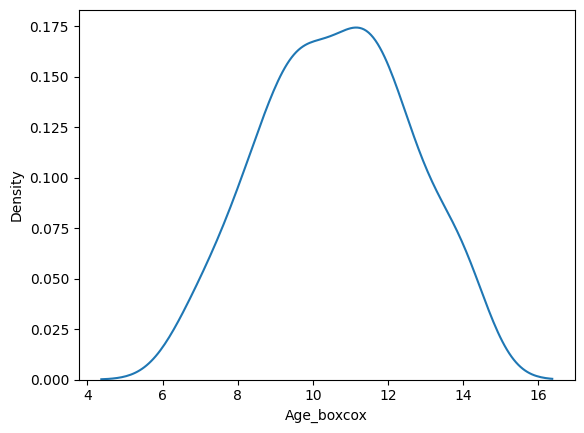

In [116]:
boxcox_transformation(final_df, 'Age')

In [117]:
from scipy.stats import yeojohnson

def yeojohnson_transformation(data, column_name):
    transformed_data, _ = yeojohnson(data[column_name])
    data[f'{column_name}_yeojohnson'] = transformed_data
    stat, p_value = shapiro(data[f'{column_name}_yeojohnson'])
    kdeplot = sns.kdeplot(data[f'{column_name}_yeojohnson'])
    
    print(kdeplot)
    print('P value: ', p_value)

Axes(0.125,0.11;0.775x0.77)
P value:  0.09733558372635087


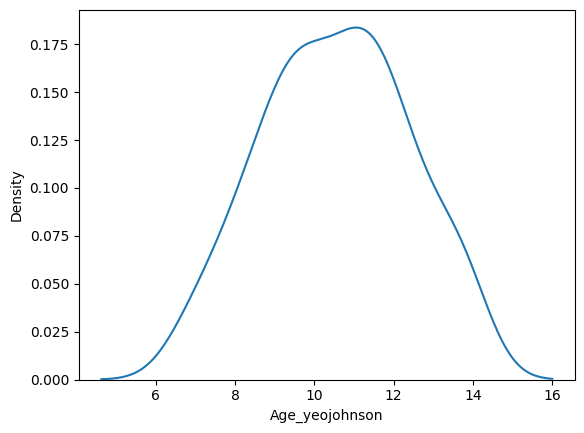

In [118]:
yeojohnson_transformation(final_df,'Age')


In [119]:
from scipy import stats
preprocessed_data = final_df.drop(['Age', 'Age_boxcox', 'Age_yeojohnson'], axis = 1)
preprocessed_data.head()


,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000,4.587424
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414,5.060314
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106,3.719700
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952,4.209591
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226,3.965810


In [120]:
churned_customers = preprocessed_data.query('Churn_Status == "Yes"')['Average_Purchase_Amount']
existing_customers = preprocessed_data.query('Churn_Status == "No"')['Average_Purchase_Amount']

t_stat,P_value = stats.ttest_ind(churned_customers, existing_customers)
print('p-value:', P_value)

if P_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in Average Purchase Amount between churned and existing customers.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in Average Purchase Amount")

p-value: 1.077550720319439e-13
Reject the null hypothesis: There is a significant difference in Average Purchase Amount between churned and existing customers.


In [121]:
churned_customers.mean()


np.float64(114.96134545454547)

In [122]:
existing_customers.mean()

np.float64(76.42560465116279)

In [123]:
stat, p_value = shapiro(preprocessed_data['Frequency_of_Purchases'])
print(p_value)

0.112461684234337


In [124]:
chicago_cust = preprocessed_data.query('City == "Chicago"')['Frequency_of_Purchases']
newyork_cust = preprocessed_data.query('City == "New York"')['Frequency_of_Purchases']
houston_cust = preprocessed_data.query('City == "Houston"')['Frequency_of_Purchases']
losangeles_cust = preprocessed_data.query('City == "Los Angeles"')['Frequency_of_Purchases']

Test_stat, p_value = stats.f_oneway(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print("P value: ", p_value)

if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

P value:  0.09375619087068889
Fail to reject the null hypothesis


In [125]:
from scipy.stats import levene
stats,p_value = levene(chicago_cust, newyork_cust, houston_cust, losangeles_cust)
print('P-value:',p_value )

P-value: 0.5007918375821501


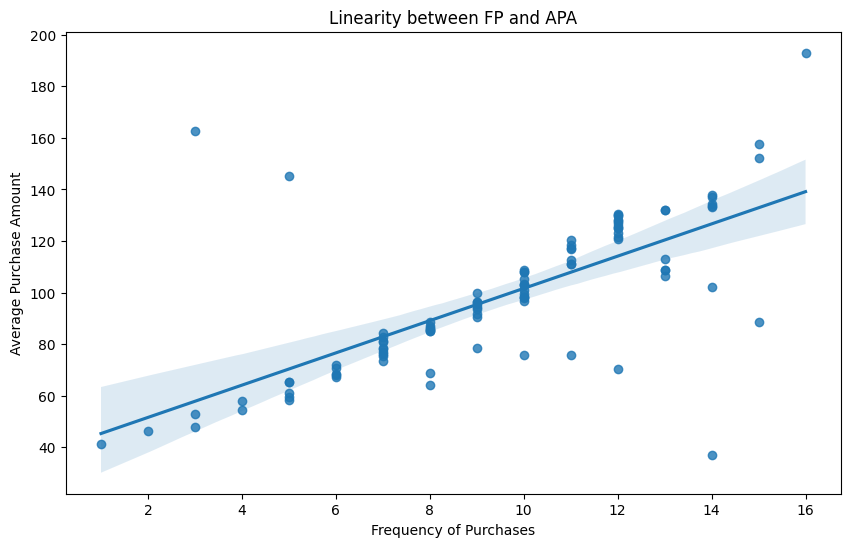

In [126]:
plt.figure(figsize =(10,6))
sns.regplot(x = 'Frequency_of_Purchases', y = 'Average_Purchase_Amount', data = preprocessed_data)
plt.title('Linearity between FP and APA')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Average Purchase Amount')
plt.show()

In [127]:
from scipy.stats import pearsonr
purchase_frequency = preprocessed_data['Frequency_of_Purchases']
purchase_amount = preprocessed_data['Average_Purchase_Amount']
corr,p_value = pearsonr(purchase_frequency, purchase_amount)
print('Pearson correlation coefficient:', corr)
print('P-value:', p_value)
if p_value < 0.05:
    print('Reject the null hypothesis')
else:
    print('Fail to reject the null hypothesis')

Pearson correlation coefficient: 0.7039911501130026
P-value: 6.176786543555055e-16
Reject the null hypothesis


In [128]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [129]:
import statsmodels.api as sm

x = preprocessed_data['Frequency_of_Purchases']
y = preprocessed_data['Average_Purchase_Amount']

# Add intercept
X = sm.add_constant(x)

# Fit OLS model
model = sm.OLS(y, X).fit()

# Display summary
print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Average_Purchase_Amount   R-squared:                       0.496
Model:                                 OLS   Adj. R-squared:                  0.490
Method:                      Least Squares   F-statistic:                     94.33
Date:                     Fri, 03 Jul 2026   Prob (F-statistic):           6.18e-16
Time:                             20:58:03   Log-Likelihood:                -435.04
No. Observations:                       98   AIC:                             874.1
Df Residuals:                           96   BIC:                             879.3
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [130]:
predicted_Apa = 39.0765 + (6.2551 * 70)
print(predicted_Apa)

476.9335


Feature engineering

In [131]:
preprocessed_data['Customer_value'] = preprocessed_data['Frequency_of_Purchases'] * preprocessed_data['Average_Purchase_Amount']

In [132]:
preprocessed_data['CLV'] = preprocessed_data['Customer_value'] * preprocessed_data['Customer_Lifespan_Months']
preprocessed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Date_of_Purchase,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log,Customer_value,CLV
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,2022-03-05 00:00:00,Yes,3,2,2,7.000000,4.587424,982.410,2947.230
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,2023-07-08 00:00:00,Yes,3,3,3,6.164414,5.060314,2364.600,9458.400
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,2023-01-30 00:00:00,No,4,4,4,4.123106,3.719700,41.252,41.252
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,2023-06-01 00:00:00,No,2,2,2,5.830952,4.209591,403.974,403.974
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,2022-09-23 00:00:00,No,1,1,1,5.477226,3.965810,158.289,158.289


In [133]:
preprocessed_data['Date_of_Purchase'] = preprocessed_data['Date_of_Purchase'].astype('datetime64[ns]')
preprocessed_data['Year'] = preprocessed_data['Date_of_Purchase'].dt.year
preprocessed_data['Month'] = preprocessed_data['Date_of_Purchase'].dt.month
preprocessed_data['Day'] = preprocessed_data['Date_of_Purchase'].dt.day

In [134]:
preprocessed_data = preprocessed_data.drop('Date_of_Purchase', axis=1)
preprocessed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log,Customer_value,CLV,Year,Month,Day
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,Yes,3,2,2,7.000000,4.587424,982.410,2947.230,2022,3,5
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,Yes,3,3,3,6.164414,5.060314,2364.600,9458.400,2023,7,8
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,No,4,4,4,4.123106,3.719700,41.252,41.252,2023,1,30
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,No,2,2,2,5.830952,4.209591,403.974,403.974,2023,6,1
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,No,1,1,1,5.477226,3.965810,158.289,158.289,2022,9,23


In [135]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
preprocessed_data['Churn_Status'] = encoder.fit_transform(preprocessed_data['Churn_Status'])
preprocessed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,Recency,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log,Customer_value,CLV,Year,Month,Day
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,3,2,2,7.000000,4.587424,982.410,2947.230,2022,3,5
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,3,3,3,6.164414,5.060314,2364.600,9458.400,2023,7,8
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,4,4,4,4.123106,3.719700,41.252,41.252,2023,1,30
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,2,2,2,5.830952,4.209591,403.974,403.974,2023,6,1
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,1,1,1,5.477226,3.965810,158.289,158.289,2022,9,23


In [136]:
preprocessed_data['engagement_level'] = pd.cut(preprocessed_data['Customer_Lifespan_Months'], bins=[0,2,3,5], labels=['Low', 'Medium', 'High'], include_lowest=True)
preprocessed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,...,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log,Customer_value,CLV,Year,Month,Day,engagement_level
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,...,2,2,7.000000,4.587424,982.410,2947.230,2022,3,5,Medium
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,...,3,3,6.164414,5.060314,2364.600,9458.400,2023,7,8,High
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,...,4,4,4.123106,3.719700,41.252,41.252,2023,1,30,Low
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,...,2,2,5.830952,4.209591,403.974,403.974,2023,6,1,Low
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,...,1,1,5.477226,3.965810,158.289,158.289,2022,9,23,Low


In [137]:
mapping = {'Low': 1, 'Medium': 2, 'High': 3}
preprocessed_data['engagement_level'] = preprocessed_data['engagement_level'].map(mapping)
preprocessed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,...,Frequency_Score,Monetary_Score,Age_sqrt,Average_Purchase_Amount_log,Customer_value,CLV,Year,Month,Day,engagement_level
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,...,2,2,7.000000,4.587424,982.410,2947.230,2022,3,5,2
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,...,3,3,6.164414,5.060314,2364.600,9458.400,2023,7,8,3
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,...,4,4,4.123106,3.719700,41.252,41.252,2023,1,30,1
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,...,2,2,5.830952,4.209591,403.974,403.974,2023,6,1,1
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,...,1,1,5.477226,3.965810,158.289,158.289,2022,9,23,1


In [138]:
dummies = pd.get_dummies(preprocessed_data[['Gender','City','Region','Purchase_Channel']], dtype=int)
processed_data = pd.concat([preprocessed_data, dummies], axis=1)
processed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,...,Gender_Male,City_Chicago,City_Houston,City_Los Angeles,City_New York,Region_Midwest,Region_Northeast,Region_West,Purchase_Channel_In-store,Purchase_Channel_Online
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,...,1,1,0,0,0,0,1,0,0,1
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,...,0,0,0,0,1,0,0,1,1,0
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,...,1,0,0,0,1,0,1,0,0,1
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,...,1,1,0,0,0,1,0,0,1,0
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,...,1,0,1,0,0,1,0,0,0,1


In [139]:
x_reg = processed_data.drop(['CustomerID', 'Gender','Region','City','Purchase_Channel','CLV'],axis=1)
y_reg = processed_data['CLV']

In [140]:
x_class = processed_data.drop(['CustomerID','City', 'Gender','Region','Purchase_Channel','Churn_Status'], axis=1)
y_class = processed_data['Churn_Status']

In [141]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_x_reg = scaler.fit_transform(x_reg)
print(scaled_x_reg)

[[ 0.77203698  0.1759198   0.0065207  ... -0.72886899 -0.7125253
   0.7125253 ]
 [-0.92657088  1.71521804  2.06462675 ...  1.37198868  1.40345893
  -1.40345893]
 [ 0.27942297 -2.59481703 -1.96808166 ... -0.72886899 -0.7125253
   0.7125253 ]
 ...
 [ 0.82757758 -1.97909774  2.23416349 ...  1.37198868  1.40345893
  -1.40345893]
 [-0.58441068 -1.36337844  1.64066362 ... -0.72886899  1.40345893
  -1.40345893]
 [-0.32642081  1.40735839 -2.11627472 ... -0.72886899  1.40345893
  -1.40345893]]


In [142]:
from sklearn.preprocessing import MinMaxScaler
scaler2 = MinMaxScaler()
scaled_x_class = scaler2.fit_transform(x_class)
print(scaled_x_class)

[[0.6183912  0.6        0.39255211 ... 0.         0.         1.        ]
 [0.27515169 0.93333333 0.77314171 ... 1.         1.         0.        ]
 [0.51884816 0.         0.02740419 ... 0.         0.         1.        ]
 ...
 [0.62961435 0.13333333 0.80449283 ... 1.         1.         0.        ]
 [0.34429237 0.26666667 0.6947415  ... 0.         1.         0.        ]
 [0.39642466 0.86666667 0.         ... 0.         1.         0.        ]]


In [143]:
from sklearn.decomposition import PCA
pca = PCA()
temp_pca = pca.fit_transform(x_reg)
evr = pca.explained_variance_ratio_

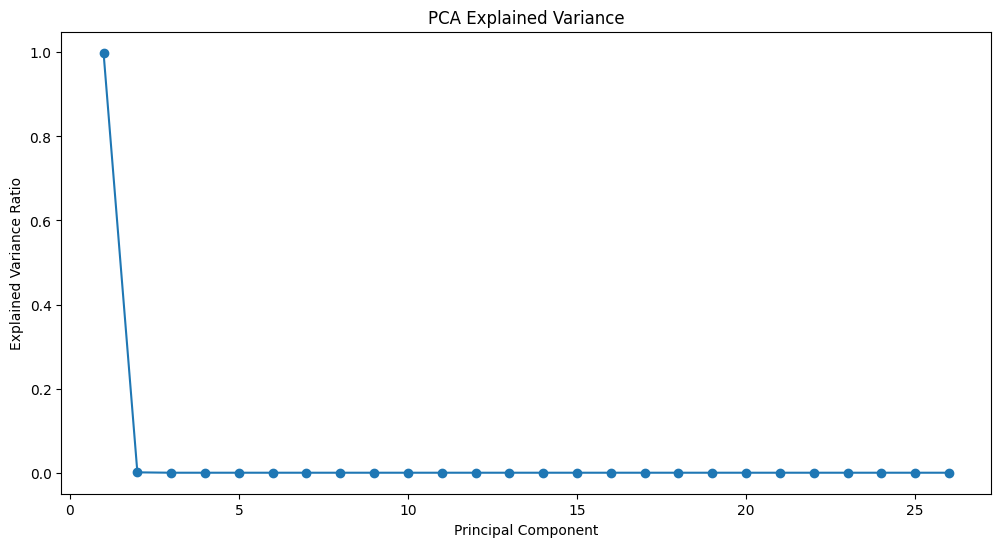

In [144]:
plt.figure(figsize=(12,6))
plt.plot(range(1, len(evr)+1), evr, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.show()

In [145]:
pca = PCA(n_components=1)
x_reg_pca = pca.fit_transform(x_reg)

In [146]:
x_reg_pca

array([[ 14373.01560228],
       [-17249.38356611],
       [  5201.60849015],
       [  -101.23328922],
       [ 20757.65810743],
       [ 18339.1471148 ],
       [  2217.96375301],
       [-19730.22289455],
       [ 14974.23918999],
       [  7210.05960872],
       [-30172.9793355 ],
       [ 20285.88550562],
       [-12922.95926645],
       [ 12334.11987952],
       [-25631.03026789],
       [  1083.06312798],
       [ 17595.33197786],
       [ 28599.15373938],
       [-17019.59986232],
       [-21081.21971088],
       [-16388.31228776],
       [ 20856.82260722],
       [ 47055.42131799],
       [-30470.75218521],
       [-12891.74270145],
       [-24450.28019795],
       [  9452.42173713],
       [  2912.03719555],
       [  1382.25216242],
       [ -7459.66461147],
       [ 23862.21994594],
       [ -2918.77982108],
       [ 40458.81833556],
       [ 20072.2666633 ],
       [ -8092.17847667],
       [-14660.2652957 ],
       [ 25628.88451671],
       [ 14568.63044942],
       [ -63

Linear Regression

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(scaled_x_reg, y_reg, test_size=0.2, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)
y_pred = lin_reg.predict(x_test)
print('Predicted CLV:', y_pred)

Predicted CLV: [2506.72403818 4867.38707308 4960.49787125 7252.47366196 2763.59860305
 5412.62093883 1872.5964791  5114.76634229 2809.33809894 2613.64197355
 4549.27848275 7248.21482445 1360.70530817 7323.7705004  1459.94094508
  381.42338538 7380.68339494 3086.82709422 -132.62468044  129.5258454 ]


In [148]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 241.64417204450598
RMSE: 280.2283473719544


Logistic Regression with K-Fold

In [149]:
x_class_train, x_class_test, y_class_train, y_class_test = train_test_split(scaled_x_class, y_class, test_size=0.2, random_state=42)

In [150]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
log_reg = LogisticRegression(max_iter=1000)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(log_reg, x_class_train, y_class_train, cv=skf, scoring='accuracy')

print(f"Cross-Validation Scores: {scores}")
print(f"Mean Accuracy: {scores.mean():.4f}")


Cross-Validation Scores: [1.         0.75       0.9375     0.93333333 0.93333333]
Mean Accuracy: 0.9108


c:\Users\thapa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\thapa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\thapa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\thapa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\thapa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


Lasso and Ridge

In [151]:
from sklearn.linear_model import Lasso, Ridge 

lasso_model = Lasso(alpha = 0.5, max_iter = 1000)
lasso_model.fit(x_train,y_train)
y_pred_lasso = lasso_model.predict(x_test)
print('predicted clv (Lasso):', y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
print("Mean Squared Error (Lasso):", mse_lasso)

ridge_model = Ridge(alpha = 0.5, max_iter = 1000)
ridge_model.fit(x_train,y_train)
y_pred_ridge = ridge_model.predict(x_test)
print('predicted clv (Ridge):', y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
print("Mean Squared Error (Ridge):", mse_ridge)


predicted clv (Lasso): [2514.67860292 4869.34829689 4957.89539395 7255.73969385 2750.91715387
 5401.53380094 1881.5293902  5122.78458163 2807.36700247 2616.26741176
 4551.6568968  7239.20529894 1356.98208092 7326.359272   1460.27979278
  370.30041527 7380.55774022 3096.0001057  -121.8961952   129.77884399]
Mean Squared Error (Lasso): 78858.85700935156
predicted clv (Ridge): [2620.76411357 4974.44910639 5117.34344679 7354.04157861 2822.01679575
 5609.07357439 2016.93453041 5102.45681246 2765.90726088 2670.44043196
 4539.35776387 7185.91839995 1319.5064797  7401.78285592 1529.43036555
  187.72332309 7368.20020734 3169.00505205  236.57390299  133.94919748]
Mean Squared Error (Ridge): 68498.40330296937


Cluster Analysis 

In [152]:
from sklearn.cluster import KMeans

In [153]:
x = processed_data[['Recency', 'Frequency_Score', 'Monetary_Score']]
wcss = []
for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x)
    wcss_score = kmeans.inertia_
    wcss.append(wcss_score)

Text(0, 0.5, 'WCSS')

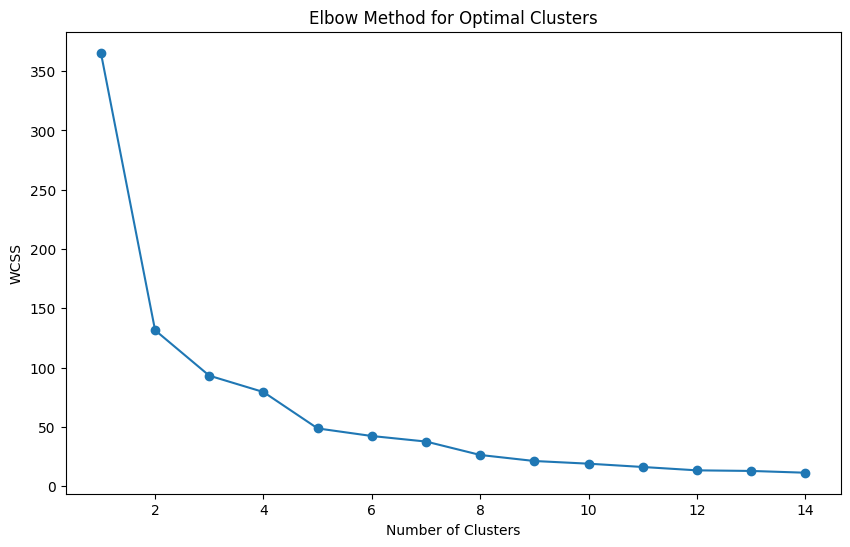

In [154]:
plt.figure(figsize =(10,6))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')


In [155]:
final_km = KMeans(n_clusters= 2)
final_km.fit(x)

labels = final_km.labels_
labels

array([1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0], dtype=int32)

In [156]:
processed_data['Cluster'] = labels
processed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,...,City_Chicago,City_Houston,City_Los Angeles,City_New York,Region_Midwest,Region_Northeast,Region_West,Purchase_Channel_In-store,Purchase_Channel_Online,Cluster
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,...,1,0,0,0,0,1,0,0,1,1
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,...,0,0,0,1,0,0,1,1,0,0
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,...,0,0,0,1,0,1,0,0,1,0
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,...,1,0,0,0,1,0,0,1,0,1
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,...,0,1,0,0,1,0,0,0,1,1


In [157]:
processed_data.groupby('Cluster')[['Recency', 'Frequency_Score', 'Monetary_Score']].mean().round(2)

,Recency,Frequency_Score,Monetary_Score
Cluster,,,
0,3.46,3.41,3.35
1,1.68,1.64,1.52


In [158]:
mapping = {0: 'Regular Customer', 1: 'Loyal Customer'}
processed_data['Customer_Type'] = processed_data['Cluster'].map(mapping)
processed_data.head(5)

,CustomerID,Gender,Income,City,Region,Frequency_of_Purchases,Average_Purchase_Amount,Customer_Lifespan_Months,Purchase_Channel,Churn_Status,...,City_Houston,City_Los Angeles,City_New York,Region_Midwest,Region_Northeast,Region_West,Purchase_Channel_In-store,Purchase_Channel_Online,Cluster,Customer_Type
0,C001,Male,72504.0,Chicago,Northeast,10,98.241,3,Online,1,...,0,0,0,0,1,0,0,1,1,Loyal Customer
1,C002,Female,40881.0,New York,West,15,157.640,4,In-store,1,...,0,0,1,0,0,1,1,0,0,Regular Customer
2,C003,Male,63333.0,New York,Northeast,1,41.252,1,Online,0,...,0,0,1,0,1,0,0,1,0,Regular Customer
3,C004,Male,58030.0,Chicago,Midwest,6,67.329,1,In-store,0,...,0,0,0,1,0,0,1,0,1,Loyal Customer
4,C005,Male,78889.0,Houston,Midwest,3,52.763,1,Online,0,...,1,0,0,1,0,0,0,1,1,Loyal Customer
